#  Enrollment Demand Forecasting with Recurrent Neural Networks (LSTM)

## FlexiSAF — Generative AI & Data Science (Advanced) Curriculum

---

## Introduction


| Resource | Why Forecasting Matters |
|---|---|
| **Classrooms** | Avoid over- or under-provisioning rooms |
| **Hostel Beds** | Ensure accommodation matches student demand |
| **Teachers** | Hire or reassign faculty ahead of time |
| **Budget** | Forecast tuition revenue for financial planning |

### Approach
Our dataset tracks **1,000 students** over **18 months** with academic metrics (CGPA, attendance, etc.). We will:
1. Treat each student's **CGPA trajectory** as an individual time series
2. Train an **LSTM** (Long Short-Term Memory) neural network to predict the next month's CGPA
3. Aggregate individual predictions into a **school-wide enrollment forecast** students whose predicted CGPA stays above a threshold are counted as "likely to remain enrolled"

> **Why LSTM?** Unlike simple feedforward networks, LSTMs have internal *memory gates* that remember patterns across many time steps perfect for capturing trends like a gradually improving or declining CGPA.

In [15]:
# IMPORTS & CONFIGURATION
import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

%matplotlib inline
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


---
## 1. Data Loading & Exploration

We load `student_placement_timeseries.csv`, a **panel dataset** from Kaggle that tracks 1,000 students on a monthly basis (January 2023 – June 2024 → 18 months).

Key columns:
- `student_id`  unique student identifier
- `month_index` sequential month number (1–18)
- `cgpa` cumulative GPA (our forecasting target)
- `attendance_percentage`, `aptitude_score`, `soft_skills_rating` — performance indicators
- `placement_status`  0 (not placed) / 1 (placed)

In [16]:
# LOAD & INSPECT THE DATA

df = pd.read_csv('student_placement_timeseries.csv')

# Parse the date column so we can plot on a proper time axis
df['date'] = pd.to_datetime(df['date'])

# Basic info
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Unique students: {df['student_id'].nunique():,}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()} "
      f"({df['date'].nunique()} months)")
print()
df.info()

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
display(df.describe())

# Missing values check
missing = df.isnull().sum()
if missing.sum() == 0:
    print("\n No missing values found in the dataset.")
else:
    print("\n Missing values detected:")
    print(missing[missing > 0])

DATASET OVERVIEW
Shape: 18,000 rows × 14 columns
Unique students: 1,000
Date range: 2023-01-01 → 2024-06-01 (18 months)

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      18000 non-null  datetime64[us]
 1   student_id                18000 non-null  int64         
 2   month_index               18000 non-null  int64         
 3   cgpa                      18000 non-null  float64       
 4   attendance_percentage     18000 non-null  float64       
 5   aptitude_score            18000 non-null  float64       
 6   soft_skills_rating        18000 non-null  float64       
 7   internships_count         18000 non-null  int64         
 8   projects_count            18000 non-null  int64         
 9   certifications_count      18000 non-null  int64         
 10  coding_practice_hours     18000 

,date,student_id,month_index,cgpa,attendance_percentage,aptitude_score,soft_skills_rating,internships_count,projects_count,certifications_count,coding_practice_hours,mock_interviews_attended,active_backlogs,placement_status
0,2023-01-01,1,1,7.27,82.9,62.1,3.54,0,0,0,6.5,0,0,0
1,2023-02-01,1,2,7.30,81.9,72.3,3.77,0,0,0,11.3,0,0,0
2,2023-03-01,1,3,7.31,75.8,67.5,3.56,0,0,0,7.4,0,0,0
3,2023-04-01,1,4,7.52,72.2,75.2,3.84,0,0,0,8.4,0,0,0
4,2023-05-01,1,5,7.45,85.0,59.9,3.93,0,0,0,6.5,0,0,0



SUMMARY STATISTICS


,date,student_id,month_index,cgpa,attendance_percentage,aptitude_score,soft_skills_rating,internships_count,projects_count,certifications_count,coding_practice_hours,mock_interviews_attended,active_backlogs,placement_status
count,18000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,2023-09-15 22:40:00,500.500000,9.500000,7.234928,82.143228,63.175906,3.288350,0.730722,1.594167,0.756444,7.400383,0.916389,0.233111,0.316444
min,2023-01-01 00:00:00,1.000000,1.000000,4.770000,36.000000,16.900000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023-05-01 00:00:00,250.750000,5.000000,6.680000,75.200000,52.600000,2.790000,0.000000,1.000000,0.000000,4.800000,0.000000,0.000000,0.000000
50%,2023-09-16 00:00:00,500.500000,9.500000,7.250000,82.700000,63.200000,3.290000,0.000000,1.000000,1.000000,7.400000,0.000000,0.000000,0.000000
75%,2024-02-01 00:00:00,750.250000,14.000000,7.760000,89.600000,74.000000,3.760000,1.000000,2.000000,1.000000,9.900000,1.000000,0.000000,1.000000
max,2024-06-01 00:00:00,1000.000000,18.000000,10.000000,100.000000,100.000000,5.000000,7.000000,8.000000,6.000000,20.400000,8.000000,3.000000,1.000000
std,NaN,288.683009,5.188272,0.818616,10.345848,15.702933,0.697332,0.903223,1.239084,0.903729,3.532572,1.212313,0.627263,0.465101



 No missing values found in the dataset.


---
## 2. Exploratory Data Analysis (EDA)

Before modelling, let's visually inspect the data for **trends**, **seasonality**, and **anomalies**. These plots help school administrators understand the raw patterns before the LSTM attempts to learn them.

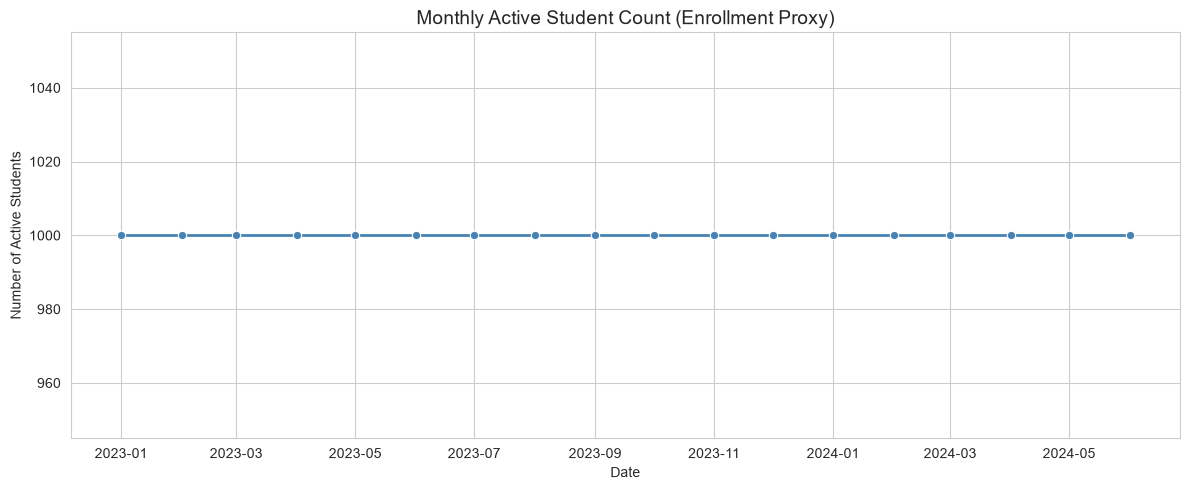

In [17]:
# PLOT 1: Monthly Active Student Count (Enrollment Proxy)

plt.figure(figsize=(12, 5))
active_students = df.groupby('date')['student_id'].nunique()
sns.lineplot(x=active_students.index, y=active_students.values,
             marker='o', linewidth=2, color='steelblue')
plt.title('Monthly Active Student Count (Enrollment Proxy)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Active Students')
plt.tight_layout()
plt.show()

**Observation:** In this dataset, all 1,000 students are tracked every month so the active count stays constant. In production, drops here would directly reveal attrition a key signal for enrollment planning.

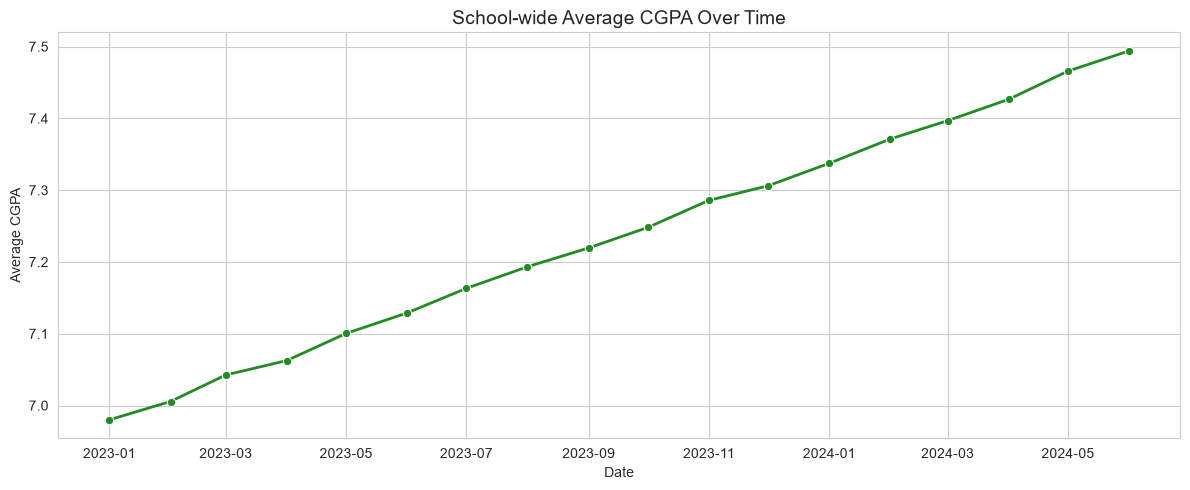

In [18]:
# PLOT 2: School-wide Average CGPA Trend

plt.figure(figsize=(12, 5))
avg_cgpa = df.groupby('date')['cgpa'].mean()
sns.lineplot(x=avg_cgpa.index, y=avg_cgpa.values,
             marker='o', linewidth=2, color='forestgreen')
plt.title('School-wide Average CGPA Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Average CGPA')
plt.tight_layout()
plt.show()

**Observation:** The school-wide average CGPA trend reveals the overall academic health of the institution. An upward trend is encouraging; a downward trend may signal systemic issues (curriculum difficulty, cohort quality) and can predict future enrollment dips.

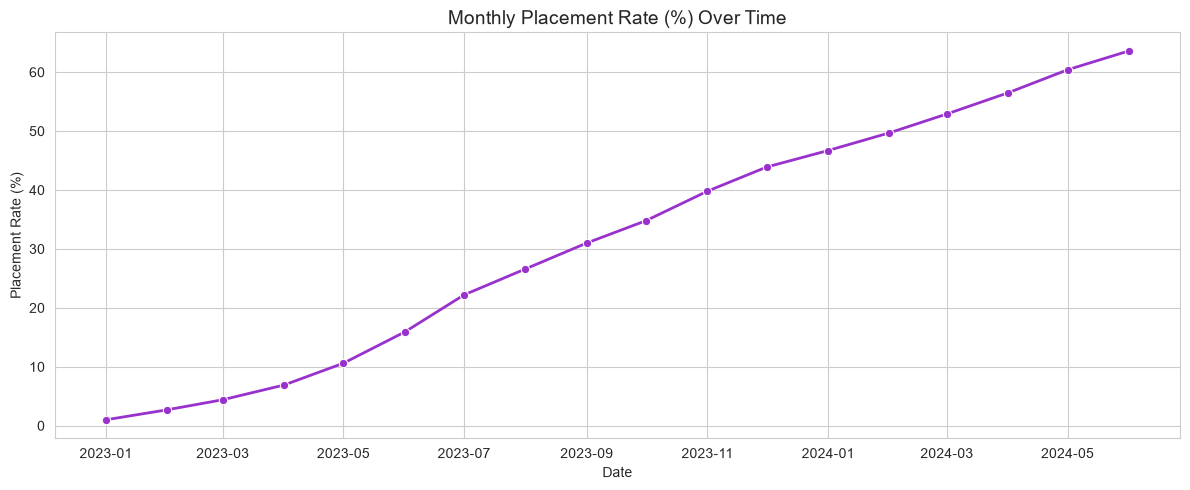

In [19]:
# PLOT 3: Monthly Placement Rate (%) Over Time

plt.figure(figsize=(12, 5))
placement_rate = df.groupby('date')['placement_status'].mean() * 100
sns.lineplot(x=placement_rate.index, y=placement_rate.values,
             marker='o', linewidth=2, color='darkorchid')
plt.title('Monthly Placement Rate (%) Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Placement Rate (%)')
plt.tight_layout()
plt.show()

**Observation:** Placement rates directly impact a school's reputation and, in turn, future enrollment demand. Rising placement rates attract more applicants, while falling rates may deter prospective students.

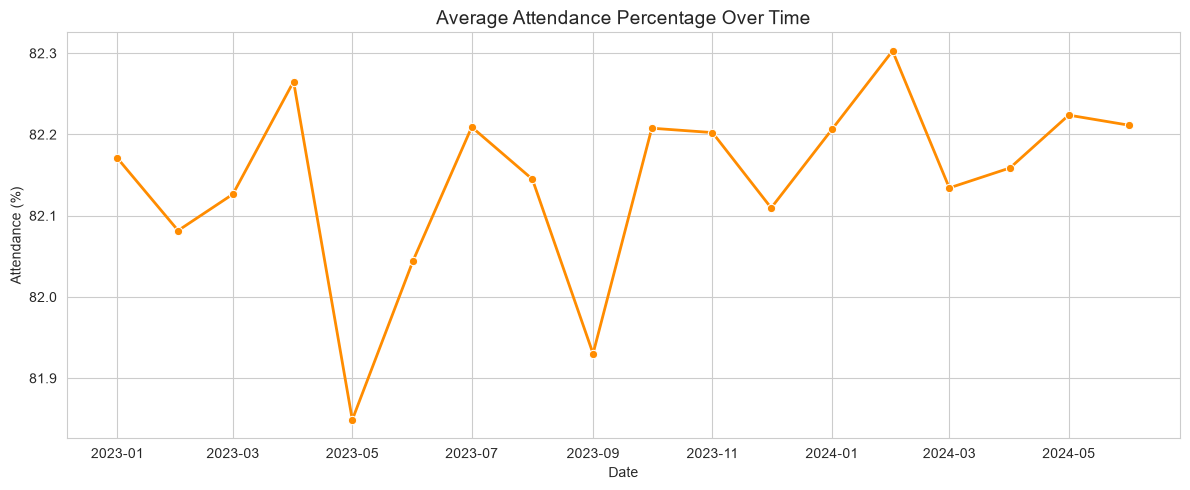

In [20]:
# PLOT 4: Average Attendance Percentage Trend

plt.figure(figsize=(12, 5))
avg_attendance = df.groupby('date')['attendance_percentage'].mean()
sns.lineplot(x=avg_attendance.index, y=avg_attendance.values,
             marker='o', linewidth=2, color='darkorange')
plt.title('Average Attendance Percentage Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Attendance (%)')
plt.tight_layout()
plt.show()

**Observation:** Declining attendance is a leading indicator of student disengagement and eventual dropout. Monitoring this metric helps counselors intervene early.

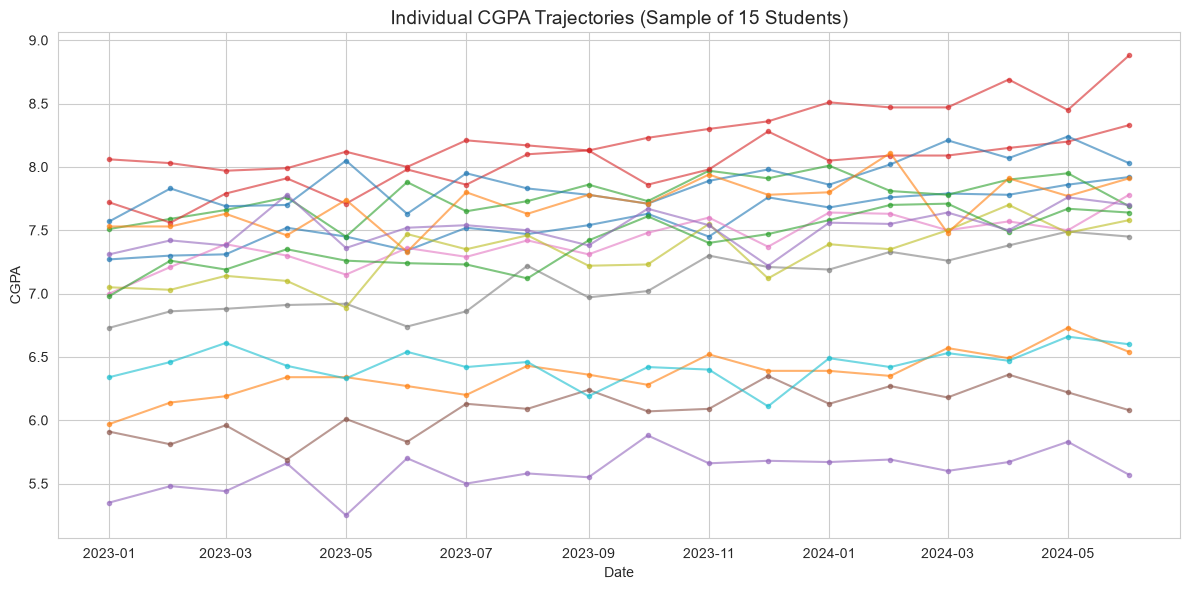

In [21]:
# PLOT 5: Individual CGPA Trajectories (Spaghetti Plot)

plt.figure(figsize=(12, 6))
sample_students = df['student_id'].unique()[:15]  # Pick 15 students
for sid in sample_students:
    sdata = df[df['student_id'] == sid]
    plt.plot(sdata['date'], sdata['cgpa'], marker='.', alpha=0.6)

plt.title('Individual CGPA Trajectories (Sample of 15 Students)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('CGPA')
plt.tight_layout()
plt.show()

**📊 Observation:** Each student follows a unique trajectory — some improve steadily, others plateau, and some decline. This diversity is why we model each student individually and then aggregate for enrollment forecasts.

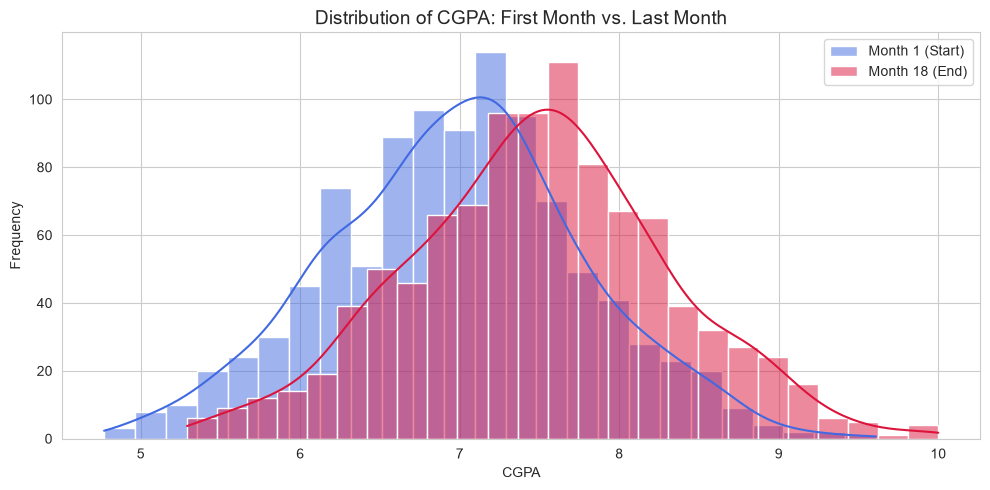

In [22]:
# PLOT 6: CGPA Distribution — First Month vs. Last Month
plt.figure(figsize=(10, 5))
first_month = df['month_index'].min()
last_month  = df['month_index'].max()

sns.histplot(df[df['month_index'] == first_month]['cgpa'],
             color='royalblue', label=f'Month {first_month} (Start)', kde=True, alpha=0.5, bins=25)
sns.histplot(df[df['month_index'] == last_month]['cgpa'],
             color='crimson', label=f'Month {last_month} (End)', kde=True, alpha=0.5, bins=25)

plt.title('Distribution of CGPA: First Month vs. Last Month', fontsize=14)
plt.xlabel('CGPA')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**📊 Observation:** Comparing the CGPA distributions at the start vs. end of the observation window reveals whether the student body is generally improving, staying flat, or declining. A rightward shift indicates improvement; leftward indicates concern.

---
## 3. Data Preprocessing for LSTM

### Strategy
1. **Pivot** the panel data so each row is one student and columns are months 1–18 (values = CGPA)
2. **Scale** with `MinMaxScaler` fitted only on training data (months 1–12) to prevent data leakage
3. **Create sliding windows** of `look_back = 6` months → predict the next month
4. **Time-based split**: train on sequences from months 1–12, test on months 13–18

>  **Why fit the scaler on training data only?** If we scale using information from the test period, we "leak" future knowledge into training, leading to over-optimistic results.

In [23]:
# DATA PREPROCESSING FOR LSTM

# Step 1: Pivot — each row = student, each column = month, values = CGPA
cgpa_pivot = df.pivot(index='student_id', columns='month_index', values='cgpa')
print(f"Pivot table shape: {cgpa_pivot.shape}  (students × months)")
display(cgpa_pivot.head())

# Step 2: Scale with MinMaxScaler
# IMPORTANT: We fit the scaler on TRAINING CGPA values only (months 1-12).
# Since all values are the same type (CGPA), we flatten to 1D to fit a single
# min/max pair, then reshape back.
scaler = MinMaxScaler(feature_range=(0, 1))

# Flatten all training CGPAs into a single column to fit
train_cgpas = cgpa_pivot.iloc[:, :12].values.flatten().reshape(-1, 1)
scaler.fit(train_cgpas)  # Learns min & max from months 1-12 only

# Apply the scaler to ALL 18 months (flatten → scale → reshape)
cgpa_array  = cgpa_pivot.values                           # (1000, 18)
cgpa_scaled = scaler.transform(
    cgpa_array.flatten().reshape(-1, 1)
).reshape(cgpa_array.shape)                                # (1000, 18)

print(f"\nScaled data shape: {cgpa_scaled.shape}")
print(f"Scaled value range: [{cgpa_scaled.min():.4f}, {cgpa_scaled.max():.4f}]")

# Step 3: Create sliding-window sequences
look_back = 6   # Use 6 months of history to predict the next month

X_train, y_train = [], []
X_test,  y_test  = [], []

for i in range(cgpa_scaled.shape[0]):          # Loop over each student
    series = cgpa_scaled[i]                     # 18-step CGPA series

    # --- TRAINING: targets at indices 6–11 (months 7–12) ---
    for j in range(look_back, 12):
        X_train.append(series[j - look_back : j])   # 6-month input window
        y_train.append(series[j])                    # Next month target

    # --- TESTING: targets at indices 12–17 (months 13–18) ---
    for j in range(12, 18):
        X_test.append(series[j - look_back : j])
        y_test.append(series[j])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

# Reshape to 3-D for Keras LSTM: [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], look_back, 1))
X_test  = X_test.reshape((X_test.shape[0],  look_back, 1))

print(f"\n{'='*50}")
print(f"Training set  →  X: {X_train.shape}   y: {y_train.shape}")
print(f"Test set      →  X: {X_test.shape}    y: {y_test.shape}")
print(f"{'='*50}")
print(f"Each sample: {look_back}-month window → predict next month's CGPA")
print(f"Training windows per student: {12 - look_back} = {X_train.shape[0] // cgpa_scaled.shape[0]}")
print(f"Test windows per student: 6")

Pivot table shape: (1000, 18)  (students × months)


month_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
student_id,,,,,,,,,,,,,,,,,,
1,7.27,7.30,7.31,7.52,7.45,7.34,7.52,7.47,7.54,7.63,7.45,7.76,7.68,7.76,7.79,7.78,7.86,7.92
2,5.97,6.14,6.19,6.34,6.34,6.27,6.20,6.43,6.36,6.28,6.52,6.39,6.39,6.35,6.57,6.49,6.73,6.54
3,7.51,7.59,7.66,7.76,7.45,7.88,7.65,7.73,7.86,7.73,7.97,7.91,8.01,7.81,7.78,7.90,7.95,7.69
4,7.72,7.56,7.79,7.91,7.71,7.98,7.86,8.10,8.13,7.86,7.98,8.28,8.05,8.09,8.09,8.15,8.20,8.33
5,5.35,5.48,5.44,5.66,5.25,5.70,5.50,5.58,5.55,5.88,5.66,5.68,5.67,5.69,5.60,5.67,5.83,5.57



Scaled data shape: (1000, 18)
Scaled value range: [0.0000, 1.0316]

Training set  →  X: (6000, 6, 1)   y: (6000,)
Test set      →  X: (6000, 6, 1)    y: (6000,)
Each sample: 6-month window → predict next month's CGPA
Training windows per student: 6 = 6
Test windows per student: 6


---
## 4. LSTM Model Architecture

We build a **Sequential LSTM** network:

| Layer | Purpose |
|---|---|
| **LSTM(64)** | First recurrent layer learns temporal patterns from 6-month windows. `return_sequences=True` passes the full hidden state to the next LSTM. |
| **Dropout(0.2)** | Randomly drops 20% of connections during training to prevent overfitting |
| **LSTM(32)** | Second recurrent layer extracts higher-level patterns |
| **Dropout(0.2)** | More regularization |
| **Dense(16, relu)** | Fully connected layer adds non-linear capacity |
| **Dense(1)** | Single output the predicted next-month CGPA |

> **Alternative models to consider:**
> - **GRU** (Gated Recurrent Unit): Simpler than LSTM with fewer parameters, often trains faster with comparable results
> - **Bidirectional LSTM**: Reads the sequence forwards *and* backwards can capture richer context
> - **Transformer-based models**: State-of-the-art for long sequences, but may be overkill for 6-step windows

In [24]:
# BUILD THE LSTM MODEL
model = Sequential([
    # First LSTM layer: 64 units, returns sequences for stacking
    LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    
    # Second LSTM layer: 32 units, returns only the final output
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    
    # Dense layers for final regression
    Dense(16, activation='relu'),
    Dense(1)   # Single output: predicted CGPA (scaled)
])

# Compile with Adam optimizer and Mean Squared Error loss
model.compile(optimizer='adam', loss='mse')

# Display the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 6, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

---
## 5. Model Training

We train for **50 epochs** with a batch size of 32. A 10% validation split from the training data lets us monitor for overfitting: if validation loss starts *increasing* while training loss keeps *decreasing*, the model is memorizing rather than learning.

> **What to watch for in the loss curves:**
> -  Both curves decreasing and converging → good generalization
> -  Validation loss increasing → early stopping or more dropout needed
> -  Both curves stuck high → model may be too small or learning rate too low

Epoch 1/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - loss: 0.0129 - val_loss: 0.0011
Epoch 2/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 3/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 4/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017 - val_loss: 8.0442e-04
Epoch 5/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0014 - val_loss: 8.4204e-04
Epoch 6/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012 - val_loss: 8.2234e-04
Epoch 7/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 9.2162e-04
Epoch 8/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 7.9036e-04
Epoch 9/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 7.7672e-04
Epoch 10/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 7.9925e-04
Epoch 11/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 7.9532e-04
Epoch 12/50
169/16

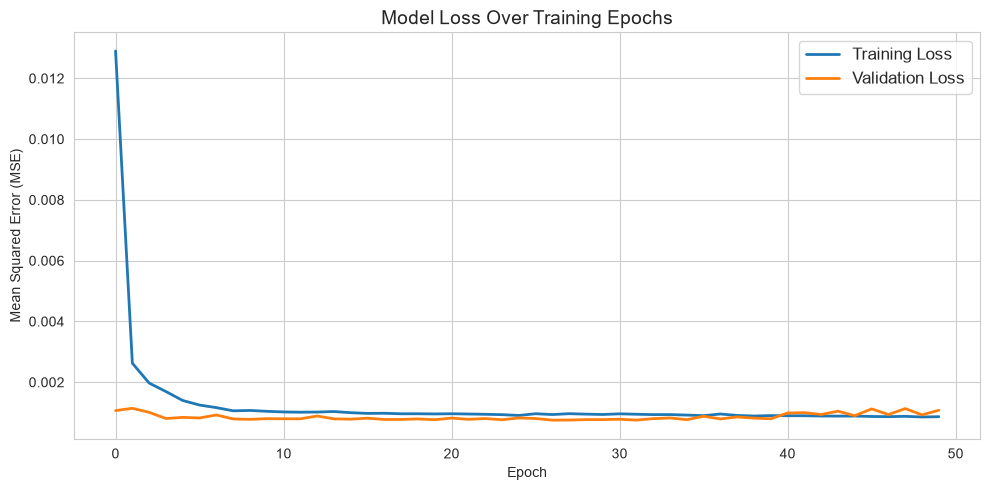


Final Training Loss:   0.000864
Final Validation Loss: 0.001077


In [25]:
# CELL: TRAIN THE MODEL
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,    # Use 10% of training data for validation
    verbose=1
)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Training Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nFinal Training Loss:   {history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")

---
## 6. Predictions & Evaluation

Now we evaluate the trained LSTM on the **held-out test set** (months 13–18). We:
1. Generate predictions (in scaled space)
2. Inverse-transform back to original CGPA values
3. Compute RMSE and MAE
4. Visualize predicted vs. actual trajectories for sample students

TEST SET EVALUATION (Original CGPA Scale)
  RMSE : 0.1808
  MAE  : 0.1425

  (Lower is better. For reference, CGPA ranges ~5.0–10.0)


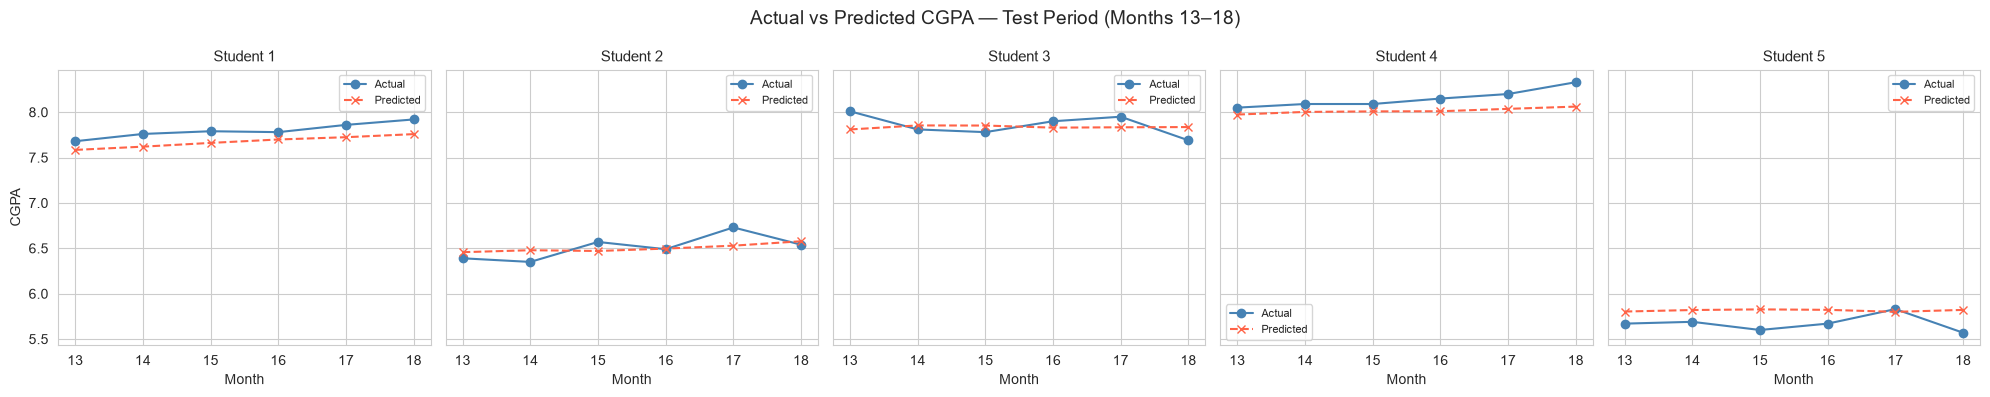

In [26]:
# PREDICTIONS & METRICS

# Generate predictions (still in scaled [0,1] space)
train_preds_scaled = model.predict(X_train, verbose=0)
test_preds_scaled  = model.predict(X_test,  verbose=0)

# Inverse-transform back to original CGPA scale
# Since our scaler was fit on a 1D column, we can use inverse_transform directly
train_preds_inv = scaler.inverse_transform(train_preds_scaled).flatten()
y_train_inv     = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
test_preds_inv  = scaler.inverse_transform(test_preds_scaled).flatten()
y_test_inv      = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Calculate error metrics on the test set
rmse = np.sqrt(mean_squared_error(y_test_inv, test_preds_inv))
mae  = mean_absolute_error(y_test_inv, test_preds_inv)

print("=" * 50)
print("TEST SET EVALUATION (Original CGPA Scale)")
print("=" * 50)
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"\n  (Lower is better. For reference, CGPA ranges ~5.0–10.0)")

# --- Visualize Actual vs Predicted for sample students ---
num_students_to_plot = 5
test_steps_per_student = 6   # Months 13–18

fig, axes = plt.subplots(1, num_students_to_plot, figsize=(20, 4), sharey=True)
fig.suptitle('Actual vs Predicted CGPA — Test Period (Months 13–18)', fontsize=14)

for i, ax in enumerate(axes):
    start = i * test_steps_per_student
    end   = start + test_steps_per_student
    months = list(range(13, 19))
    
    ax.plot(months, y_test_inv[start:end], 'o-', label='Actual', color='steelblue')
    ax.plot(months, test_preds_inv[start:end], 'x--', label='Predicted', color='tomato')
    ax.set_title(f'Student {i+1}', fontsize=11)
    ax.set_xlabel('Month')
    if i == 0:
        ax.set_ylabel('CGPA')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Future Enrollment Forecasting

This is the key section for **school administrators**. We:
1. Take each student's last 6 known months (months 13–18)
2. Use the LSTM to **recursively predict** 3 months into the future (months 19–21)
3. Count how many students are predicted to maintain a CGPA > 6.0 this serves as a **proxy for continued enrollment**
4. Plot the historical trend alongside the forecast to visualize expected enrollment

> **Why CGPA > 6.0 as a threshold?** Students below this mark are at high risk of academic probation or voluntary dropout. Schools can adjust this threshold based on their policies.

Generating recursive forecasts...
  → Month 19 predicted
  → Month 20 predicted
  → Month 21 predicted


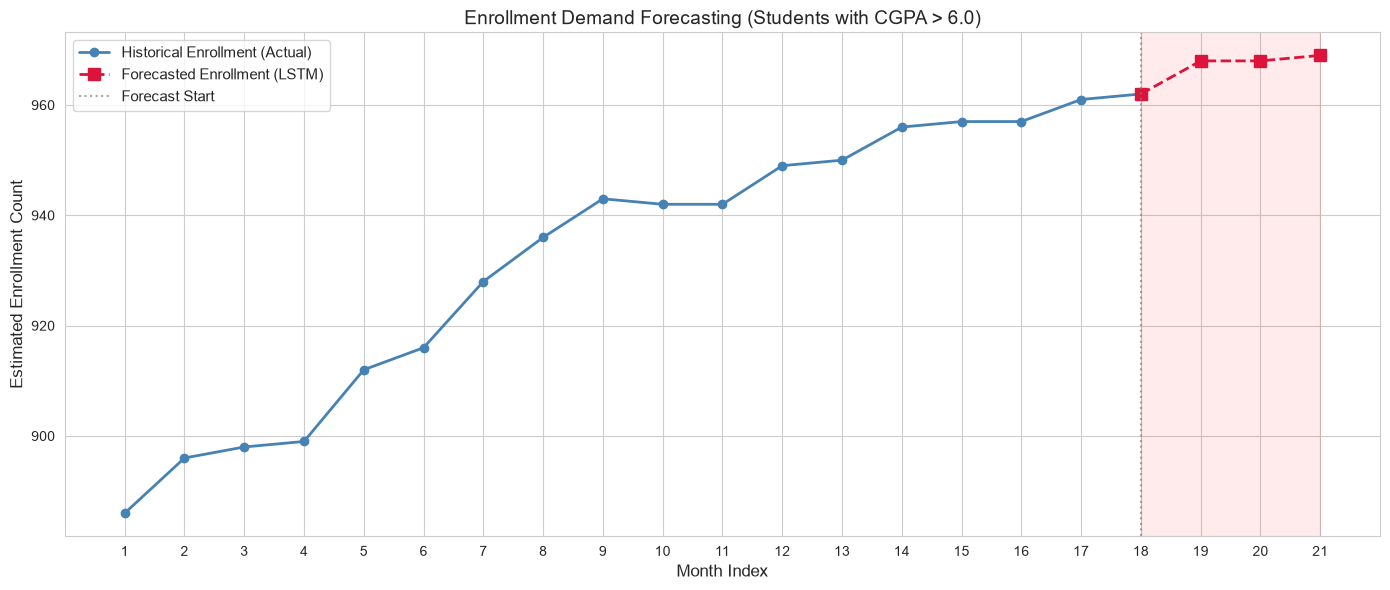


ENROLLMENT FORECAST SUMMARY
Current enrollment (Month 18):  962
Projected (Month 19):         968  (+6 students)
Projected (Month 20):         968  (+6 students)
Projected (Month 21):         969  (+7 students)


In [27]:
# RECURSIVE FUTURE FORECASTING

future_steps = 3  # Forecast 3 months ahead (months 19, 20, 21)
future_predictions = []

# Start with each student's last 6 months of scaled CGPA (months 13-18)
current_inputs = cgpa_scaled[:, -look_back:]                    # (1000, 6)
current_inputs = current_inputs.reshape((-1, look_back, 1))     # (1000, 6, 1)

print("Generating recursive forecasts...")
for step in range(future_steps):
    # Predict the next month for all 1000 students simultaneously
    next_pred = model.predict(current_inputs, verbose=0)        # (1000, 1)
    future_predictions.append(next_pred.flatten())
    
    # Slide the window: drop oldest month, append new prediction
    next_pred_3d = next_pred.reshape((-1, 1, 1))                # (1000, 1, 1)
    current_inputs = np.concatenate(
        [current_inputs[:, 1:, :], next_pred_3d], axis=1
    )                                                            # (1000, 6, 1)
    print(f"  → Month {18 + step + 1} predicted")

# Convert predictions back to original CGPA scale
future_predictions = np.array(future_predictions)               # (3, 1000)
future_preds_inv = scaler.inverse_transform(
    future_predictions.flatten().reshape(-1, 1)
).reshape(future_predictions.shape)                              # (3, 1000)


# ENROLLMENT THRESHOLD
threshold = 6.0  # Students with CGPA > 6.0 are "likely to remain enrolled"

# Historical enrollment proxy: count of students with CGPA > threshold each month
historical_enrollment = [
    (cgpa_pivot[col] > threshold).sum() for col in cgpa_pivot.columns
]

# Forecasted enrollment: same metric applied to predicted CGPAs
forecasted_enrollment = [
    (future_preds_inv[step] > threshold).sum() for step in range(future_steps)
]

# VISUALIZATION: Historical + Forecasted Enrollment
plt.figure(figsize=(14, 6))

months_hist = list(range(1, 19))             # Months 1–18 (historical)
months_fcst = list(range(18, 22))            # Months 18–21 (overlap at 18 for continuity)

# Historical line
plt.plot(months_hist, historical_enrollment, 'o-',
         color='steelblue', linewidth=2, markersize=6,
         label='Historical Enrollment (Actual)')

# Forecast line (starts at last historical point for visual continuity)
plt.plot(months_fcst, [historical_enrollment[-1]] + forecasted_enrollment, 's--',
         color='crimson', linewidth=2, markersize=8,
         label='Forecasted Enrollment (LSTM)')

# Forecast start marker
plt.axvline(x=18, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')

# Shaded forecast region
plt.axvspan(18, 21, alpha=0.08, color='red')

plt.title(f'Enrollment Demand Forecasting (Students with CGPA > {threshold})', fontsize=14)
plt.xlabel('Month Index', fontsize=12)
plt.ylabel('Estimated Enrollment Count', fontsize=12)
plt.legend(fontsize=11)
plt.xticks(range(1, 22))
plt.tight_layout()
plt.show()

# Print the forecast table
print("\n" + "=" * 50)
print("ENROLLMENT FORECAST SUMMARY")
print("=" * 50)
print(f"Current enrollment (Month 18):  {historical_enrollment[-1]}")
for step in range(future_steps):
    delta = forecasted_enrollment[step] - historical_enrollment[-1]
    sign  = '+' if delta >= 0 else ''
    print(f"Projected (Month {19 + step}):         "
          f"{forecasted_enrollment[step]}  ({sign}{delta} students)")

---
## 8. Recommendations for School Administrators

The enrollment forecast produced above can drive several critical planning decisions:

### Classroom Capacity Planning
If the forecast projects a **dip** in enrollment, administrators can:
- Consolidate class sections to optimize teacher-to-student ratios
- Repurpose underutilized classrooms for labs or study halls

If enrollment is projected to **rise**, they should:
- Begin procurement of additional desks, projectors, and learning materials
- Plan for additional class sections

### Hostel Bed Allocation
Projected enrollment counts translate directly to hostel occupancy demand. Over-provisioning wastes resources; under-provisioning leads to student dissatisfaction and overcrowding.

###  Teacher Recruitment & Scheduling
Use the forecast to:
- Determine if new teachers need to be hired for the upcoming term
- Adjust course schedules (add/remove sections) based on projected class sizes

###  Budget Forecasting
Enrollment directly impacts **tuition revenue**. By multiplying projected enrollment × tuition fee, the finance team can prepare more accurate budgets.

### Targeted Interventions
The individual-level predictions (not just the aggregate) reveal **which specific students** are predicted to fall below the CGPA threshold. Counselors can target those students with academic support *before* they drop out.

### Caveats & Limitations
- This model uses **CGPA as a proxy** for enrollment. In reality, dropout is influenced by financial, personal, and social factors not captured here.
- Recursive forecasting can suffer from **error accumulation**: predictions further into the future become less reliable.
- The model should be **retrained regularly** as new semester data becomes available.
- External shocks (pandemics, policy changes) can invalidate forecasts.

### How to Update the Model
Each semester:
1. Collect updated CGPA data for all students
2. Append to the training dataset
3. Retrain the LSTM (or use transfer learning for efficiency)
4. Generate updated enrollment forecasts

---
## 9. Conclusion

In this notebook, we:
1.  Explored 18 months of student performance data across 1,000 students
2.  Built an LSTM neural network to forecast individual CGPA trajectories
3.  Aggregated individual predictions into a school-wide enrollment forecast
4.  Projected 3 months into the future using recursive prediction

**Key takeaway :** By integrating this forecasting capability, schools can move from *reactive* resource management to *proactive* planning  ordering supplies, hiring staff, and preparing infrastructure *before* the demand materializes, not after.